# 12-Lead ECG — AFib vs Normal Sinus Rhythm (No Windowing)

**Dataset:** Large Scale 12-Lead ECG Arrhythmia Database (Chapman-Shaoxing)  
**Subset:** AFib + Normal Sinus Rhythm only (pre-filtered)  
**Task:** Binary classification — AFib vs Normal  
**Model:** KanResWideX (12 channels, all leads, 500 Hz native)  
**Input:** Full 10-second recordings (no windowing) — 1 recording = 1 sample  
**Setup:** 5-fold stratified CV by patient IDs

### Metrics:
- Accuracy, Precision, Recall, F1, MCC, AUROC, AUPRC
- TN, FP, FN, TP
- ECE, MCE, Brier Score, Calibration Curves


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install wfdb -q
print('Drive mounted and dependencies installed.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 142.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is inco

## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
!nvidia-smi


Sun May 17 11:02:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             52W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Configuration

In [4]:
class Config:
    # Pre-filtered subset folders
    afib_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset/afib"
    normal_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset/normal"

    # Signal parameters
    fs = 500              # Native 500 Hz, no downsampling
    num_channels = 12     # All 12 leads
    recording_seconds = 10
    recording_samples = fs * recording_seconds  # 5000 samples

    # Training
    num_classes = 2
    batch_size = 64
    num_epochs = 50
    learning_rate = 1e-3
    weight_decay = 1e-4
    early_stop_patience = 10
    n_folds = 5
    random_seed = 42

    # PDF output
    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_12lead"

config = Config()
assert os.path.exists(config.afib_dir), f"AFib folder not found: {config.afib_dir}"
assert os.path.exists(config.normal_dir), f"Normal folder not found: {config.normal_dir}"
os.makedirs(config.pdf_dir, exist_ok=True)

print(f"AFib dir:   {config.afib_dir}")
print(f"Normal dir: {config.normal_dir}")
print(f"Sampling rate: {config.fs} Hz (native, no downsampling)")
print(f"Leads: All 12")
print(f"Input: Full {config.recording_seconds}s recordings ({config.recording_samples} samples) — no windowing")

AFib dir:   /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset/afib
Normal dir: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset/normal
Sampling rate: 500 Hz (native, no downsampling)
Leads: All 12
Input: Full 10s recordings (5000 samples) — no windowing


## 3. Model Definition (12 Channels)

In [5]:
class KanResInit(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride)
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2)
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x

class KanResModule(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride, padding='same')
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2, padding='same')
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = out + identity
        return out

class KanResWideX(nn.Module):
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()
        self.init_block = KanResInit(input_channels, 64, 32, 8, 3, 1)
        self.pool = nn.AvgPool1d(kernel_size=2)
        self.res_modules = nn.ModuleList([
            KanResModule(32, 64, 32, 50, 50, 1) for _ in range(8)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, output_size)

    def forward(self, x):
        x = self.init_block(x)
        x = self.pool(x)
        for res_module in self.res_modules:
            x = res_module(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

print("Model defined (12-channel input).")
total_params = sum(p.numel() for p in KanResWideX().parameters())
print(f"Total parameters: {total_params:,}")

Model defined (12-channel input).
Total parameters: 1,653,346


## 4. Discover Records from Subset Folders

In [6]:
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])

all_records = []
for name in afib_files:
    all_records.append({"path": os.path.join(config.afib_dir, name), "name": name, "label": 1})
for name in normal_files:
    all_records.append({"path": os.path.join(config.normal_dir, name), "name": name, "label": 0})

print(f"AFib records:   {len(afib_files)}")
print(f"Normal records: {len(normal_files)}")
print(f"Total subset:   {len(all_records)}")
print(f"AFib prevalence: {len(afib_files)/len(all_records):.2%}")

AFib records:   1780
Normal records: 8125
Total subset:   9905
AFib prevalence: 17.97%


## 5. Load and Preprocess Signals (Full 10s, No Windowing)

In [7]:
def load_record(record_info, config):
    try:
        rec = wfdb.rdrecord(record_info["path"])
        signal = rec.p_signal  # (5000, 12)
    except Exception as e:
        return None, None

    if signal.shape[1] < config.num_channels:
        return None, None

    if np.any(np.isnan(signal)):
        return None, None

    # Use full recording — no windowing
    # Pad or trim to exactly recording_samples if needed
    if len(signal) < config.recording_samples:
        pad = np.zeros((config.recording_samples - len(signal), config.num_channels))
        signal = np.vstack([signal, pad])
    elif len(signal) > config.recording_samples:
        signal = signal[:config.recording_samples, :]

    # Z-normalize each channel
    for ch in range(config.num_channels):
        std = np.std(signal[:, ch])
        if std < 1e-6:
            return None, None
        signal[:, ch] = (signal[:, ch] - np.mean(signal[:, ch])) / std

    # Shape: (12, 5000) — one sample per patient
    sample = signal[:, :config.num_channels].T.copy().astype(np.float32)
    label = np.int64(record_info["label"])
    return sample, label

# Test on one record
s, l = load_record(all_records[0], config)
if s is not None:
    print(f"Test: {all_records[0]['name']} -> shape {s.shape}, label={l}")
    print(f"  {s.shape[0]} channels x {s.shape[1]} samples ({config.recording_seconds}s at {config.fs} Hz)")
    print(f"  1 sample per patient (no windowing)")
else:
    print("Failed to load test record")

Test: JS00001 -> shape (12, 5000), label=1
  12 channels x 5000 samples (10s at 500 Hz)
  1 sample per patient (no windowing)


In [8]:
import shutil

local_afib = "/content/afib"
local_normal = "/content/normal"

if not os.path.exists(local_afib):
    print("Copying AFib records to local disk...")
    shutil.copytree(config.afib_dir, local_afib)
    print(f"  Done: {len([f for f in os.listdir(local_afib) if f.endswith('.hea')])} records")

if not os.path.exists(local_normal):
    print("Copying Normal records to local disk...")
    shutil.copytree(config.normal_dir, local_normal)
    print(f"  Done: {len([f for f in os.listdir(local_normal) if f.endswith('.hea')])} records")

# Point config to local copies
config.afib_dir = local_afib
config.normal_dir = local_normal
print("Using local disk — loading will be much faster.")

Copying AFib records to local disk...
  Done: 1780 records
Copying Normal records to local disk...
  Done: 8125 records
Using local disk — loading will be much faster.


## 6. Load All Records

In [9]:
print(f"Loading {len(all_records)} records...")
start_time = time.time()

patient_data = {}
skipped = 0

for i, rec in enumerate(all_records):
    if (i + 1) % 2000 == 0:
        elapsed = time.time() - start_time
        print(f"  Processed {i+1}/{len(all_records)} ({elapsed:.0f}s)...")

    sample, label = load_record(rec, config)
    if sample is not None:
        patient_data[rec["name"]] = {
            "sample": sample,
            "label": label
        }
    else:
        skipped += 1

load_time = time.time() - start_time
print(f"\nLoading complete in {load_time/60:.1f} minutes")
print(f"Patients loaded: {len(patient_data)} (skipped: {skipped})")

afib_patients = sum(1 for p in patient_data.values() if p["label"] == 1)
normal_patients = sum(1 for p in patient_data.values() if p["label"] == 0)

print(f"  AFib patients:   {afib_patients}")
print(f"  Normal patients: {normal_patients}")
print(f"  Total samples:   {len(patient_data)} (1 per patient, no windowing)")

Loading 9905 records...
  Processed 2000/9905 (28s)...
  Processed 4000/9905 (55s)...
  Processed 6000/9905 (84s)...
  Processed 8000/9905 (113s)...

Loading complete in 2.3 minutes
Patients loaded: 9682 (skipped: 223)
  AFib patients:   1780
  Normal patients: 7902
  Total samples:   9682 (1 per patient, no windowing)


## 7. 5-Fold Stratified Split by Patient IDs

In [10]:
np.random.seed(config.random_seed)

patient_names = np.array(sorted(patient_data.keys()))
patient_labels = np.array([patient_data[p]["label"] for p in patient_names])

skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)

folds = []
print("=" * 90)
print("5-FOLD STRATIFIED SPLIT BY PATIENT IDs")
print("=" * 90)
print(f"\n{'Fold':<6} {'Train Pts':<12} {'Val Pts':<10} {'Train AFib':<13} {'Train Normal':<14} {'Val AFib':<11} {'Val Normal':<12} {'Val AFib %':<10}")
print("-" * 90)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(patient_names, patient_labels)):
    train_patients = patient_names[train_idx].tolist()
    val_patients = patient_names[val_idx].tolist()

    train_afib = sum(1 for p in train_patients if patient_data[p]["label"] == 1)
    train_normal = sum(1 for p in train_patients if patient_data[p]["label"] == 0)
    val_afib = sum(1 for p in val_patients if patient_data[p]["label"] == 1)
    val_normal = sum(1 for p in val_patients if patient_data[p]["label"] == 0)

    folds.append({"train": train_patients, "val": val_patients})

    val_afib_pct = val_afib / (val_afib + val_normal) * 100
    print(f"{fold_idx+1:<6} {len(train_patients):<12} {len(val_patients):<10} {train_afib:<13} {train_normal:<14} {val_afib:<11} {val_normal:<12} {val_afib_pct:<.1f}%")

print("-" * 90)
print(f"\nTotal patients: {len(patient_names)} (AFib: {sum(patient_labels)}, Normal: {len(patient_labels) - sum(patient_labels)})")
print(f"Overall AFib prevalence: {sum(patient_labels)/len(patient_labels):.2%}")

5-FOLD STRATIFIED SPLIT BY PATIENT IDs

Fold   Train Pts    Val Pts    Train AFib    Train Normal   Val AFib    Val Normal   Val AFib %
------------------------------------------------------------------------------------------
1      7745         1937       1424          6321           356         1581         18.4%
2      7745         1937       1424          6321           356         1581         18.4%
3      7746         1936       1424          6322           356         1580         18.4%
4      7746         1936       1424          6322           356         1580         18.4%
5      7746         1936       1424          6322           356         1580         18.4%
------------------------------------------------------------------------------------------

Total patients: 9682 (AFib: 1780, Normal: 7902)
Overall AFib prevalence: 18.38%


## 8. Class Distribution Visualization

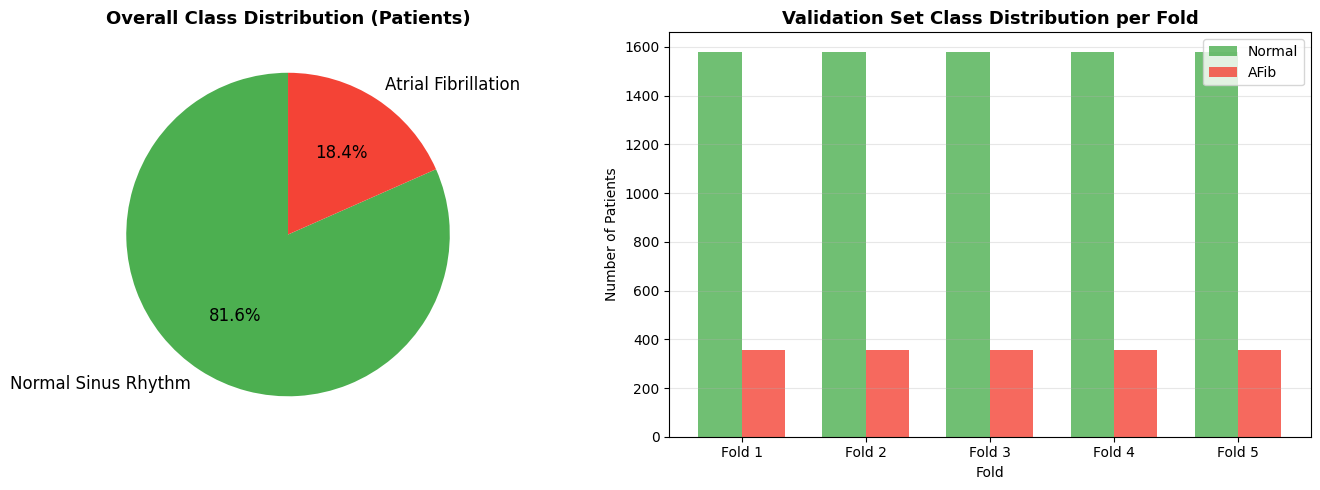

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
counts = [normal_patients, afib_patients]
labels_pie = ['Normal Sinus Rhythm', 'Atrial Fibrillation']
colors_pie = ['#4CAF50', '#F44336']
ax.pie(counts, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax.set_title('Overall Class Distribution (Patients)', fontsize=13, fontweight='bold')

ax = axes[1]
fold_nums = range(1, config.n_folds + 1)
val_afib_counts = []
val_normal_counts = []
for fold in folds:
    va = sum(1 for p in fold["val"] if patient_data[p]["label"] == 1)
    vn = sum(1 for p in fold["val"] if patient_data[p]["label"] == 0)
    val_afib_counts.append(va)
    val_normal_counts.append(vn)

x = np.arange(len(fold_nums))
width = 0.35
ax.bar(x - width/2, val_normal_counts, width, label='Normal', color='#4CAF50', alpha=0.8)
ax.bar(x + width/2, val_afib_counts, width, label='AFib', color='#F44336', alpha=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('Number of Patients')
ax.set_title('Validation Set Class Distribution per Fold', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in fold_nums])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "class_distribution.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 9. Helper Functions

In [12]:
class ECGDataset(Dataset):
    def __init__(self, samples, labels):
        self.samples = torch.FloatTensor(samples)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

def merge_patients(patient_list):
    s_list, l_list = [], []
    for p in patient_list:
        s_list.append(patient_data[p]["sample"])
        l_list.append(patient_data[p]["label"])
    return np.array(s_list, dtype=np.float32), np.array(l_list, dtype=np.int64)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return running_loss / total, correct / total

def evaluate_full(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    total = len(all_targets)
    return running_loss / total, np.array(all_targets), np.array(all_preds), np.array(all_probs)

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, pos_label=1, zero_division=0)
    rec = recall_score(targets, preds, pos_label=1, zero_division=0)
    f1 = f1_score(targets, preds, pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(targets, preds)
    auroc = roc_auc_score(targets, probs)
    auprc = average_precision_score(targets, probs)
    brier = brier_score_loss(targets, probs)
    n_bins = 10
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (probs >= bin_boundaries[i]) & (probs < bin_boundaries[i + 1])
        else:
            mask = (probs >= bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        bin_count = mask.sum()
        if bin_count > 0:
            bin_acc = targets[mask].mean()
            bin_conf = probs[mask].mean()
            cal_error = abs(bin_acc - bin_conf)
            ece += (bin_count / len(targets)) * cal_error
            mce = max(mce, cal_error)
    metrics = {"tn": tn, "fp": fp, "fn": fn, "tp": tp, "accuracy": acc, "precision": prec,
               "recall": rec, "f1": f1, "mcc": mcc, "auroc": auroc, "auprc": auprc,
               "brier": brier, "ece": ece, "mce": mce, "cm": cm}
    return metrics

print("All functions defined.")

All functions defined.


## 10. Run 5-Fold Cross-Validation

In [13]:
all_fold_metrics = []
all_fold_targets = []
all_fold_preds = []
all_fold_probs = []
all_fold_histories = []
all_fold_model_states = []

total_cv_start = time.time()

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{config.n_folds}")
    print(f"{'='*70}")

    X_train, y_train = merge_patients(fold["train"])
    X_val, y_val = merge_patients(fold["val"])
    print(f"  Train: {len(y_train):,} samples (AFib: {np.sum(y_train==1):,}, Normal: {np.sum(y_train==0):,})")
    print(f"  Val:   {len(y_val):,} samples (AFib: {np.sum(y_val==1):,}, Normal: {np.sum(y_val==0):,})")

    train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=config.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model = KanResWideX(input_channels=config.num_channels, output_size=config.num_classes).to(device)

    class_counts = Counter(y_train.tolist())
    class_weights = torch.FloatTensor([len(y_train) / (config.num_classes * class_counts[i]) for i in range(config.num_classes)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": []}

    print(f"  {'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Time':<8}")
    print(f"  {'-'*52}")

    fold_start = time.time()
    for epoch in range(1, config.num_epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, _, _, _ = evaluate_full(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        epoch_time = time.time() - epoch_start
        note = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            note = " *"
        else:
            patience_counter += 1
        print(f"  {epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {epoch_time:<.0f}s{note}")
        if patience_counter >= config.early_stop_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    fold_time = time.time() - fold_start
    model.load_state_dict(best_model_state)
    _, targets, preds, probs = evaluate_full(model, val_loader, criterion, device)
    metrics = compute_all_metrics(targets, preds, probs)

    all_fold_metrics.append(metrics)
    all_fold_targets.append(targets)
    all_fold_preds.append(preds)
    all_fold_probs.append(probs)
    all_fold_histories.append(history)
    all_fold_model_states.append(best_model_state)

    print(f"\n  Fold {fold_idx+1} ({fold_time/60:.1f} min): Acc={metrics['accuracy']:.4f} F1={metrics['f1']:.4f} MCC={metrics['mcc']:.4f} AUROC={metrics['auroc']:.4f}")
    print(f"  TN={metrics['tn']} FP={metrics['fp']} FN={metrics['fn']} TP={metrics['tp']}")
    print(f"  Brier={metrics['brier']:.4f} ECE={metrics['ece']:.4f} MCE={metrics['mce']:.4f}")

total_cv_time = time.time() - total_cv_start
print(f"\n\nTotal CV time: {total_cv_time/60:.1f} minutes")


FOLD 1/5
  Train: 7,745 samples (AFib: 1,424, Normal: 6,321)
  Val:   1,937 samples (AFib: 356, Normal: 1,581)
  Epoch    Train Loss   Train Acc    Val Loss     Time    
  ----------------------------------------------------
  1        0.2505       0.8998       0.0808       11s *
  2        0.0787       0.9731       0.0680       9s *
  3        0.0480       0.9828       0.0603       9s *
  4        0.0380       0.9863       0.0559       9s *
  5        0.0415       0.9849       0.0429       9s *
  6        0.0396       0.9877       0.0367       9s *
  7        0.0375       0.9884       0.0377       9s
  8        0.0221       0.9925       0.0293       9s *
  9        0.0176       0.9935       0.0396       9s
  10       0.0180       0.9932       0.0561       9s
  11       0.0119       0.9952       0.0271       9s *
  12       0.0179       0.9946       0.0613       9s
  13       0.0539       0.9793       0.0405       9s
  14       0.0192       0.9934       0.0446       9s
  15       0.04

## 11. Cross-Validation Summary Table

In [14]:
metric_names = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce", "tn", "fp", "fn", "tp"]

print("=" * 120)
print("5-FOLD CROSS-VALIDATION RESULTS (12-Lead, AFib vs Normal, No Windowing)")
print("=" * 120)
header = f"{'Metric':<12}"
for i in range(len(folds)):
    header += f"{'Fold '+str(i+1):<14}"
header += f"{'Mean':<14}{'Std':<14}"
print(header)
print("-" * 120)

for metric in metric_names:
    values = [m[metric] for m in all_fold_metrics]
    row = f"{metric.upper():<12}"
    for v in values:
        if metric in ["tn", "fp", "fn", "tp"]:
            row += f"{int(v):<14}"
        else:
            row += f"{v:<14.4f}"
    mean_v, std_v = np.mean(values), np.std(values)
    if metric in ["tn", "fp", "fn", "tp"]:
        row += f"{mean_v:<14.0f}{std_v:<14.0f}"
    else:
        row += f"{mean_v:<14.4f}{std_v:<14.4f}"
    print(row)
print("=" * 120)

5-FOLD CROSS-VALIDATION RESULTS (12-Lead, AFib vs Normal, No Windowing)
Metric      Fold 1        Fold 2        Fold 3        Fold 4        Fold 5        Mean          Std           
------------------------------------------------------------------------------------------------------------------------
ACCURACY    0.9923        0.9959        0.9943        0.9948        0.9923        0.9939        0.0014        
PRECISION   0.9671        0.9807        0.9778        0.9753        0.9621        0.9726        0.0069        
RECALL      0.9916        0.9972        0.9916        0.9972        0.9972        0.9949        0.0028        
F1          0.9792        0.9889        0.9847        0.9861        0.9793        0.9836        0.0038        
MCC         0.9746        0.9864        0.9812        0.9830        0.9748        0.9800        0.0047        
AUROC       0.9993        0.9999        0.9993        0.9992        0.9996        0.9994        0.0003        
AUPRC       0.9964        0.99

## 12. Confusion Matrices

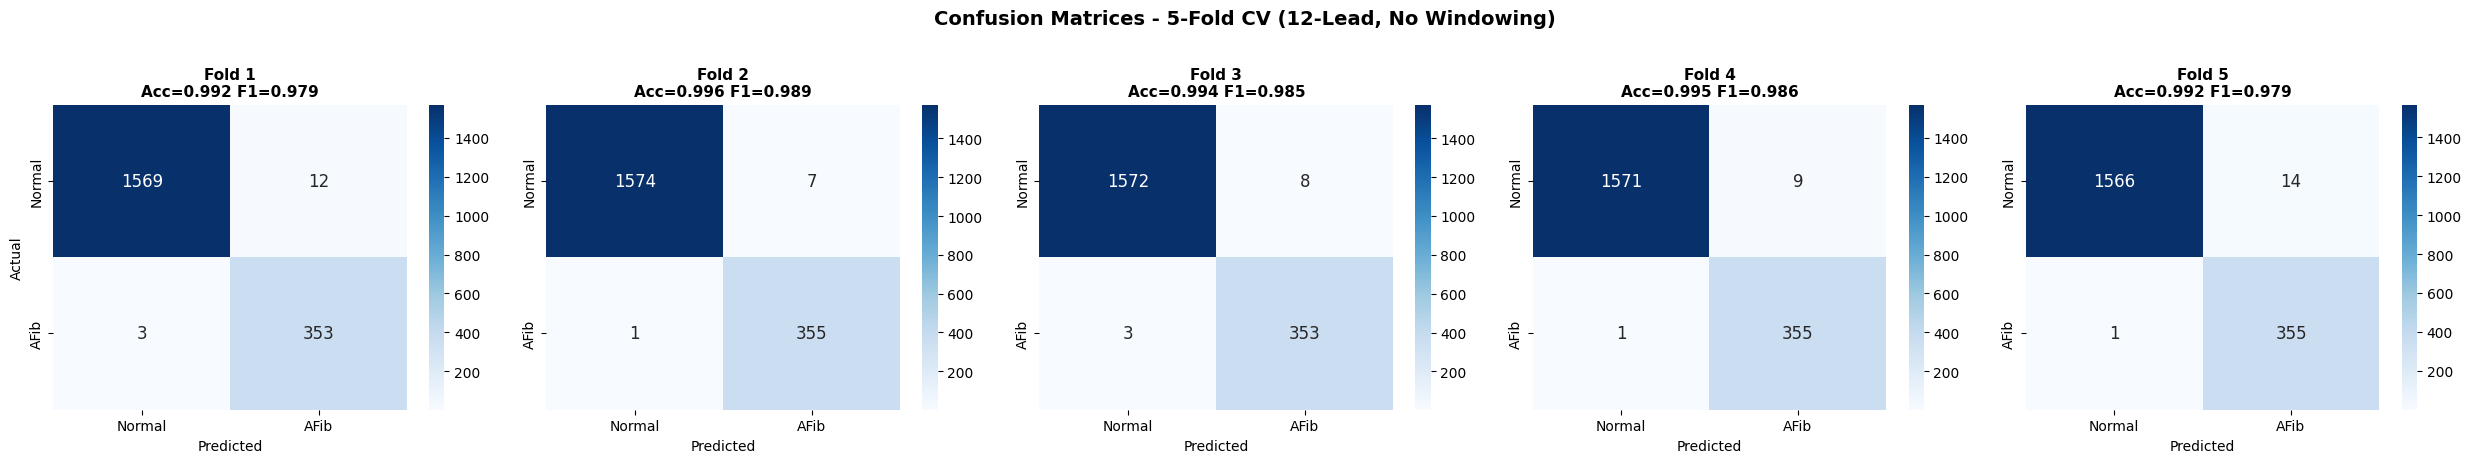

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for i, metrics in enumerate(all_fold_metrics):
    ax = axes[i]
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "AFib"], yticklabels=["Normal", "AFib"],
                ax=ax, annot_kws={"size": 12})
    ax.set_title(f"Fold {i+1}\nAcc={metrics['accuracy']:.3f} F1={metrics['f1']:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if i == 0 else "")

plt.suptitle("Confusion Matrices - 5-Fold CV (12-Lead, No Windowing)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "confusion_matrices.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 13. ROC Curves

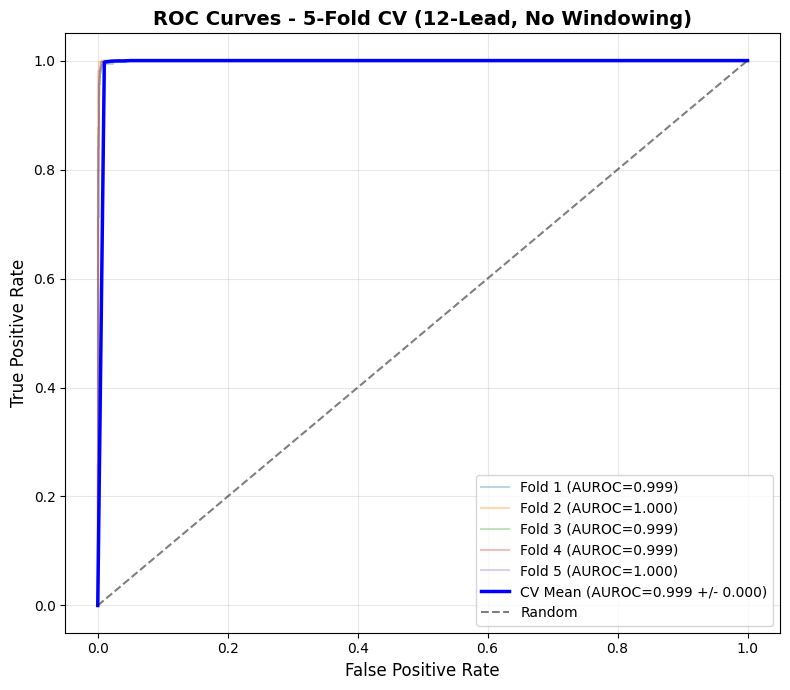

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
for i in range(len(folds)):
    fpr, tpr, _ = roc_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(fpr, tpr, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUROC={all_fold_metrics[i]["auroc"]:.3f})')
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auroc = np.mean([m["auroc"] for m in all_fold_metrics])
std_auroc = np.std([m["auroc"] for m in all_fold_metrics])
ax.plot(mean_fpr, mean_tpr, color='blue', linewidth=2.5, label=f'CV Mean (AUROC={mean_auroc:.3f} +/- {std_auroc:.3f})')
std_tpr = np.std(tprs, axis=0)
ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1), color='blue', alpha=0.1)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - 5-Fold CV (12-Lead, No Windowing)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "roc_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 14. Precision-Recall Curves

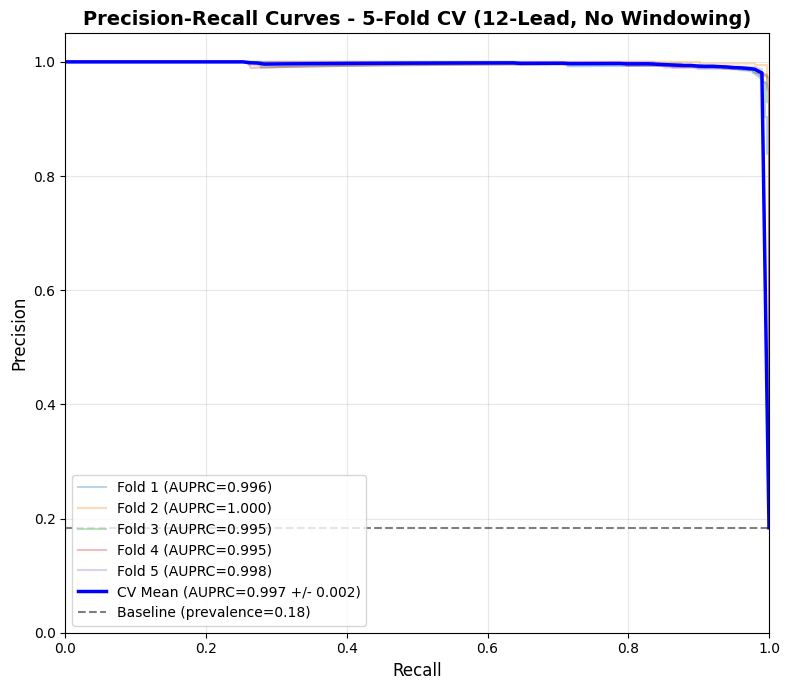

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_recall_pts = np.linspace(0, 1, 100)
precisions_interp = []
for i in range(len(folds)):
    prec_c, rec_c, _ = precision_recall_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(rec_c, prec_c, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUPRC={all_fold_metrics[i]["auprc"]:.3f})')
    prec_interp = np.interp(mean_recall_pts, rec_c[::-1], prec_c[::-1])
    precisions_interp.append(prec_interp)
mean_prec = np.mean(precisions_interp, axis=0)
mean_auprc = np.mean([m["auprc"] for m in all_fold_metrics])
std_auprc = np.std([m["auprc"] for m in all_fold_metrics])
ax.plot(mean_recall_pts, mean_prec, color='blue', linewidth=2.5, label=f'CV Mean (AUPRC={mean_auprc:.3f} +/- {std_auprc:.3f})')
std_prec = np.std(precisions_interp, axis=0)
ax.fill_between(mean_recall_pts, np.maximum(mean_prec - std_prec, 0), np.minimum(mean_prec + std_prec, 1), color='blue', alpha=0.1)
all_targets_combined = np.concatenate(all_fold_targets)
baseline = np.mean(all_targets_combined)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - 5-Fold CV (12-Lead, No Windowing)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "precision_recall_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 15. Calibration Plots (Reliability Diagrams)

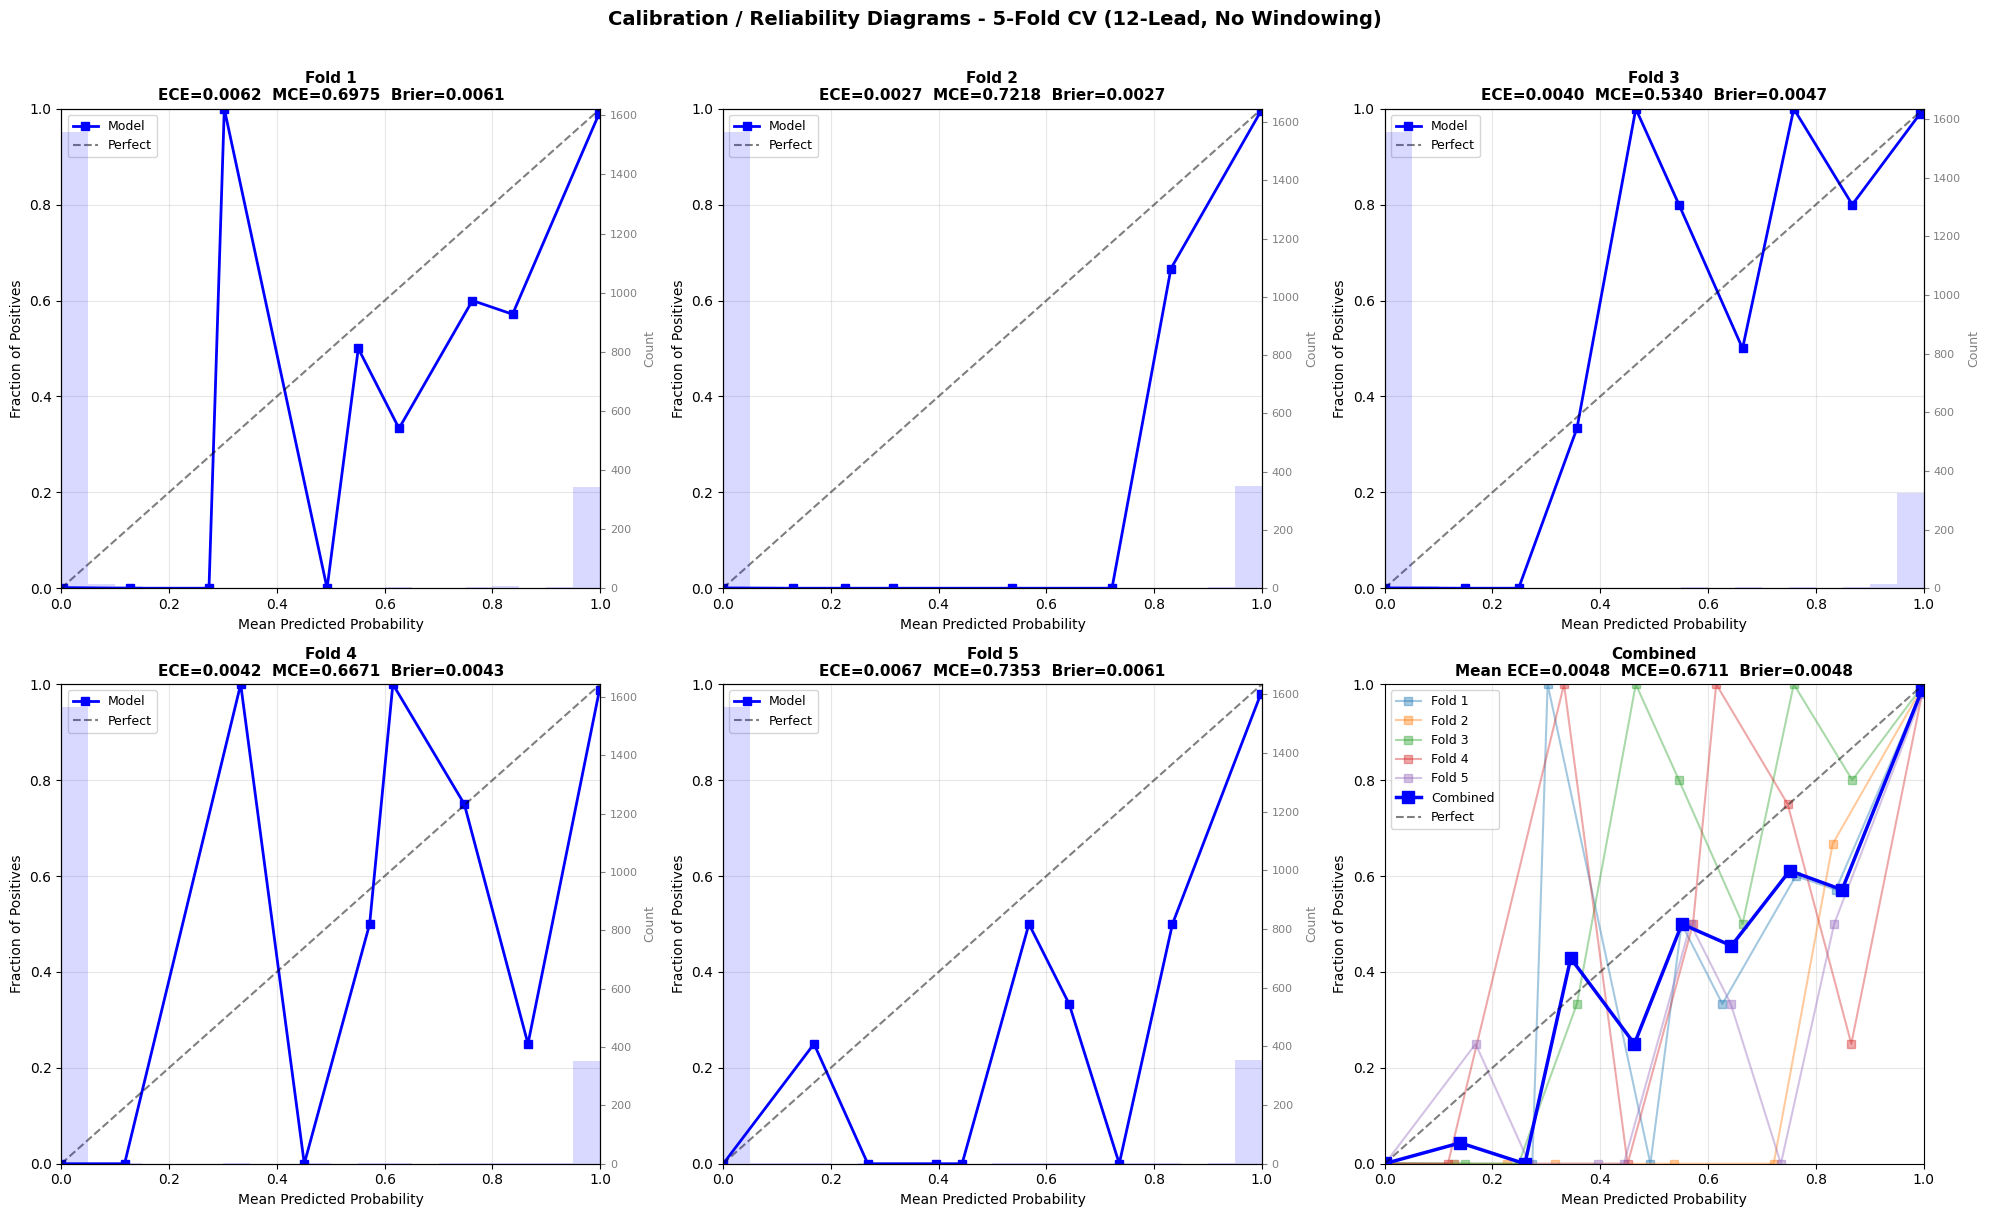

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i in range(len(folds)):
    row, col = i // 3, i % 3
    ax = axes[row][col]
    fraction_pos, mean_predicted = calibration_curve(all_fold_targets[i], all_fold_probs[i], n_bins=10, strategy='uniform')
    ax.plot(mean_predicted, fraction_pos, 's-', color='blue', linewidth=2, markersize=6, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(all_fold_probs[i], bins=20, range=(0, 1), alpha=0.15, color='blue')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    ax2.tick_params(axis='y', labelsize=8, colors='gray')
    m = all_fold_metrics[i]
    ax.set_title(f"Fold {i+1}\nECE={m['ece']:.4f}  MCE={m['mce']:.4f}  Brier={m['brier']:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

# Combined in last subplot
ax = axes[1][2]
for i in range(len(folds)):
    fraction_pos, mean_predicted = calibration_curve(all_fold_targets[i], all_fold_probs[i], n_bins=10, strategy='uniform')
    ax.plot(mean_predicted, fraction_pos, 's-', alpha=0.4, linewidth=1.5, label=f'Fold {i+1}')
all_t = np.concatenate(all_fold_targets)
all_p = np.concatenate(all_fold_probs)
frac_all, mean_all = calibration_curve(all_t, all_p, n_bins=10, strategy='uniform')
ax.plot(mean_all, frac_all, 's-', color='blue', linewidth=2.5, markersize=8, label='Combined')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
mean_ece = np.mean([m['ece'] for m in all_fold_metrics])
mean_mce = np.mean([m['mce'] for m in all_fold_metrics])
mean_brier = np.mean([m['brier'] for m in all_fold_metrics])
ax.set_title(f"Combined\nMean ECE={mean_ece:.4f}  MCE={mean_mce:.4f}  Brier={mean_brier:.4f}", fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.suptitle("Calibration / Reliability Diagrams - 5-Fold CV (12-Lead, No Windowing)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "calibration_plots.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 16. Predicted Probability Distributions

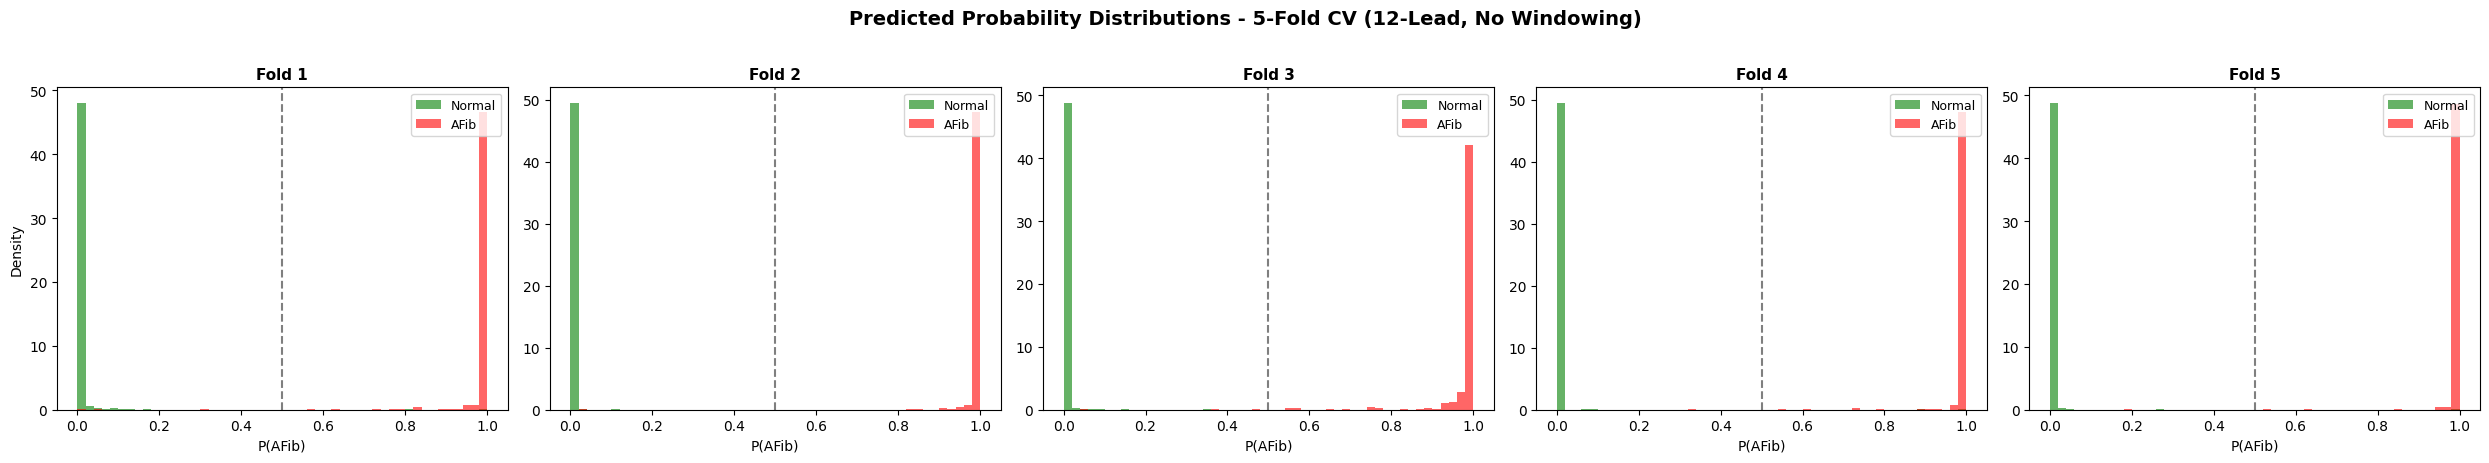

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for i in range(len(folds)):
    ax = axes[i]
    mask_neg = all_fold_targets[i] == 0
    mask_pos = all_fold_targets[i] == 1
    ax.hist(all_fold_probs[i][mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Normal', density=True)
    ax.hist(all_fold_probs[i][mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Fold {i+1}", fontsize=11, fontweight='bold')
    ax.set_xlabel("P(AFib)")
    if i == 0: ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Predicted Probability Distributions - 5-Fold CV (12-Lead, No Windowing)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "probability_distributions.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 17. Metrics Comparison Across Folds

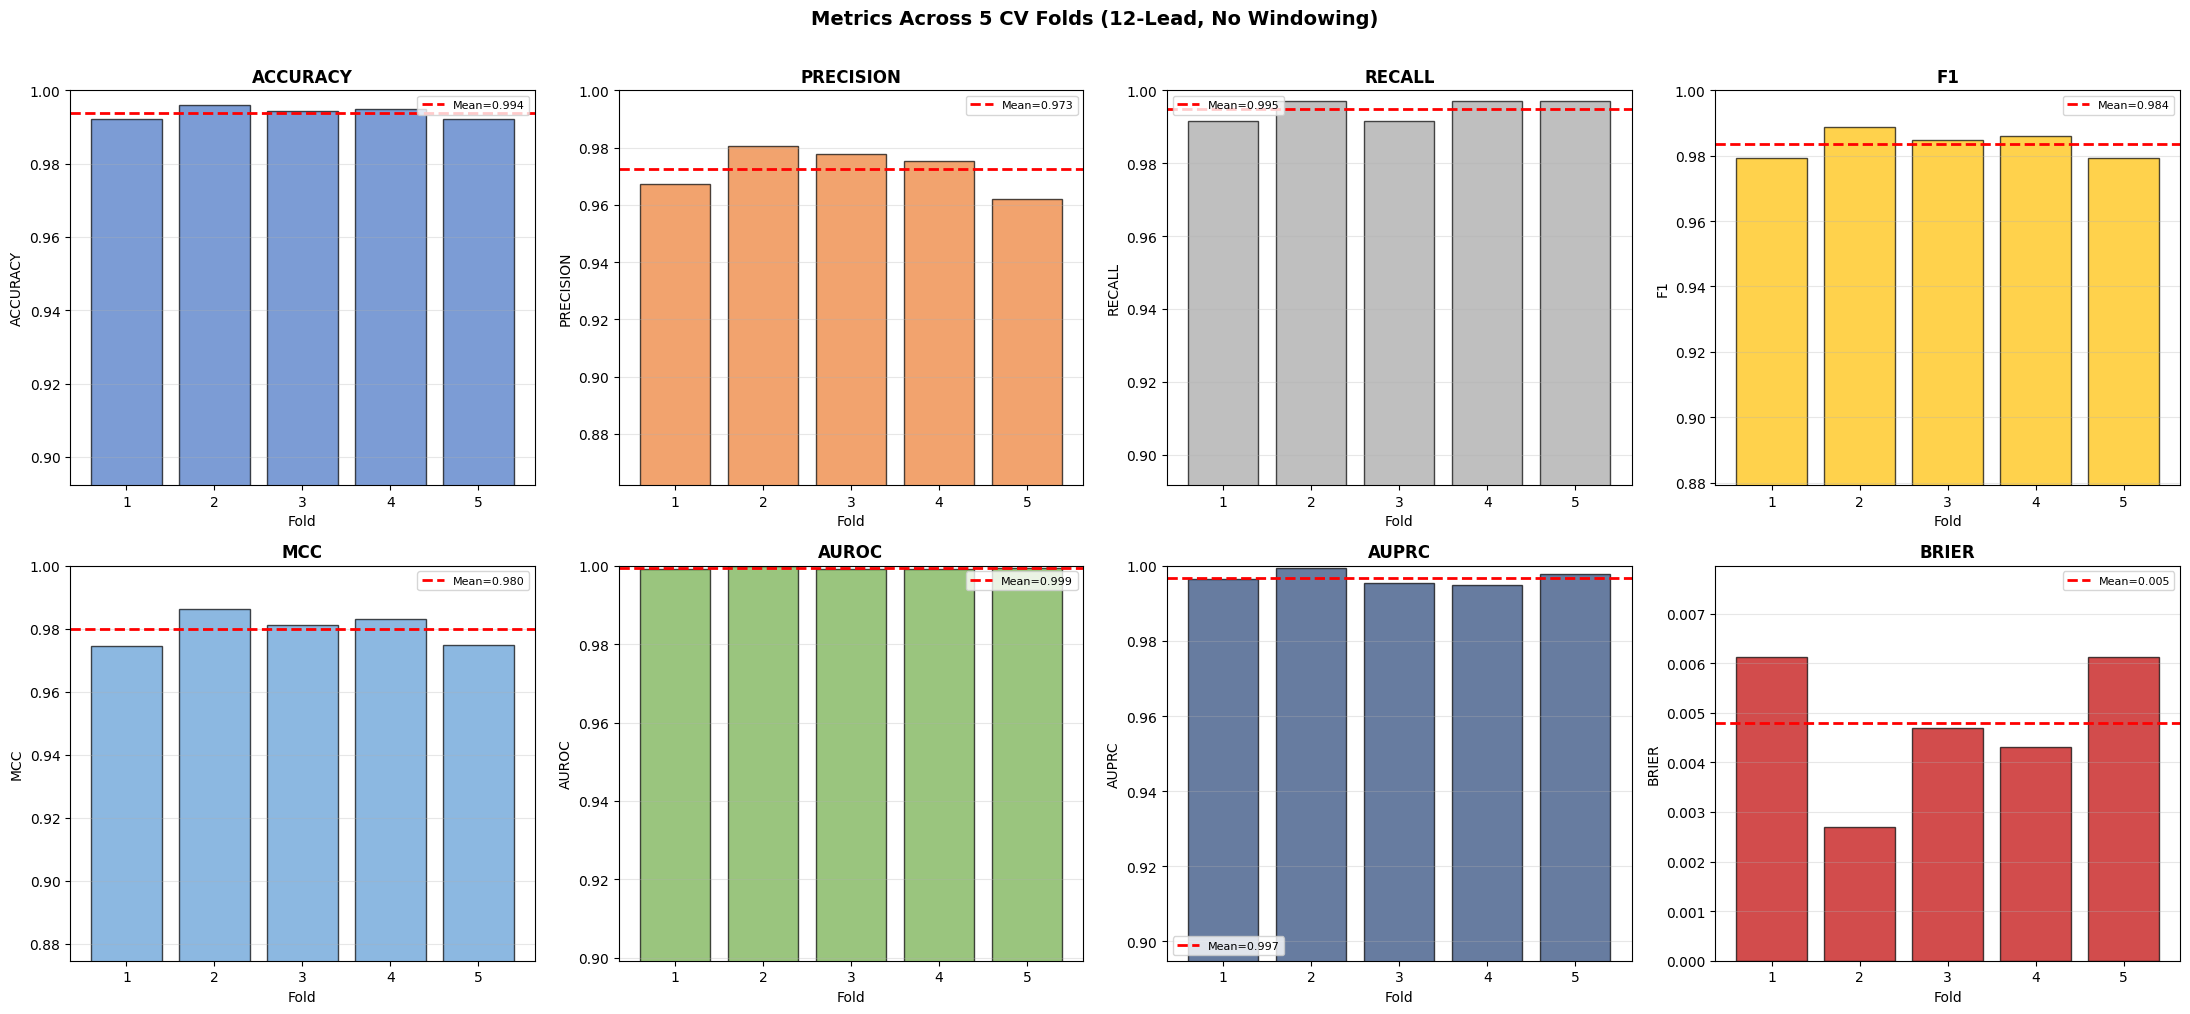

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plot_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier"]
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47', '#264478', '#C00000']
for idx, metric in enumerate(plot_metrics):
    row, col = idx // 4, idx % 4
    ax = axes[row][col]
    values = [m[metric] for m in all_fold_metrics]
    mean_val = np.mean(values)
    ax.bar(range(1, len(folds)+1), values, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_val:.3f}')
    ax.set_xlabel("Fold"); ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(folds)+1))
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    if metric == "brier": ax.set_ylim([0, max(values) * 1.3])
    else: ax.set_ylim([max(0, min(values) - 0.1), 1.0])
plt.suptitle("Metrics Across 5 CV Folds (12-Lead, No Windowing)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "metrics_comparison.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 18. Training & Validation Loss Curves

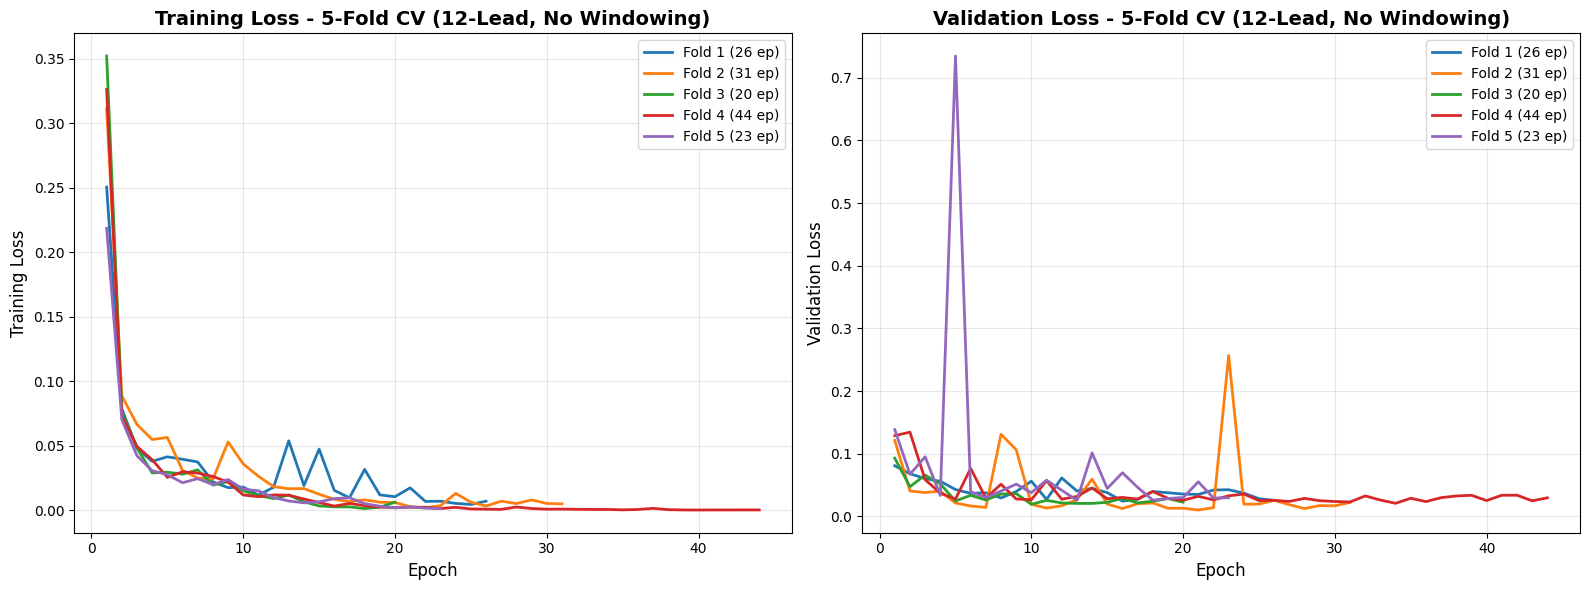

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], linewidth=2, label=f'Fold {i+1} ({len(history["train_loss"])} ep)')
ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Training Loss - 5-Fold CV (12-Lead, No Windowing)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history["val_loss"]) + 1)
    ax.plot(epochs, history["val_loss"], linewidth=2, label=f'Fold {i+1} ({len(history["val_loss"])} ep)')
ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Validation Loss - 5-Fold CV (12-Lead, No Windowing)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "training_loss_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 19. Final Summary

In [22]:
print("=" * 70)
print("FINAL 5-FOLD CV SUMMARY - 12-Lead ECG (AFib vs Normal, No Windowing)")
print("=" * 70)
print()
summary_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]
print(f"{'Metric':<20} {'Mean +/- Std':<25}")
print("-" * 45)
for m in summary_metrics:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    print(f"{m.upper():<20} {mean_v:.4f} +/- {std_v:.4f}")
print()
print(f"{'Confusion Matrix':<20} {'Mean +/- Std':<25}")
print("-" * 45)
for m in ["tn", "fp", "fn", "tp"]:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    print(f"{m.upper():<20} {mean_v:.0f} +/- {std_v:.0f}")
print()
print(f"Model: KanResWideX (12-channel)")
print(f"Input: All 12 leads at {config.fs} Hz")
print(f"Recording: Full {config.recording_seconds}s ({config.recording_samples} samples) - no windowing")
print(f"Dataset: Chapman-Shaoxing (AFib + Normal Sinus Rhythm subset)")
print(f"Patients: {len(patient_data)} (AFib: {afib_patients}, Normal: {normal_patients})")
print(f"Samples: {len(patient_data)} (1 per patient)")
print(f"Total CV time: {total_cv_time/60:.1f} minutes")

FINAL 5-FOLD CV SUMMARY - 12-Lead ECG (AFib vs Normal, No Windowing)

Metric               Mean +/- Std             
---------------------------------------------
ACCURACY             0.9939 +/- 0.0014
PRECISION            0.9726 +/- 0.0069
RECALL               0.9949 +/- 0.0028
F1                   0.9836 +/- 0.0038
MCC                  0.9800 +/- 0.0047
AUROC                0.9994 +/- 0.0003
AUPRC                0.9968 +/- 0.0017
BRIER                0.0048 +/- 0.0013
ECE                  0.0048 +/- 0.0015
MCE                  0.6711 +/- 0.0724

Confusion Matrix     Mean +/- Std             
---------------------------------------------
TN                   1570 +/- 3
FP                   10 +/- 3
FN                   2 +/- 1
TP                   354 +/- 1

Model: KanResWideX (12-channel)
Input: All 12 leads at 500 Hz
Recording: Full 10s (5000 samples) - no windowing
Dataset: Chapman-Shaoxing (AFib + Normal Sinus Rhythm subset)
Patients: 9682 (AFib: 1780, Normal: 7902)
Samples: 9682 

## 20. Save Best Model

In [23]:
val_f1s = [m["f1"] for m in all_fold_metrics]
best_fold_idx = np.argmax(val_f1s)
print(f"Best fold: Fold {best_fold_idx+1} (Val F1={val_f1s[best_fold_idx]:.4f})")

save_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "best_model_12lead.pth")
torch.save(all_fold_model_states[best_fold_idx], save_path)
print(f"Model saved to: {save_path}")

print(f"\nSaved PDF plots in: {config.pdf_dir}")
for f in sorted(os.listdir(config.pdf_dir)):
    if f.endswith('.pdf'):
        print(f"  {f}")

Best fold: Fold 2 (Val F1=0.9889)
Model saved to: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth

Saved PDF plots in: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_12lead
  calibration_plots.pdf
  class_distribution.pdf
  confusion_matrices.pdf
  metrics_comparison.pdf
  precision_recall_curves.pdf
  probability_distributions.pdf
  roc_curves.pdf
  training_loss_curves.pdf
